In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [30]:
# Set random seed for reproducibility
torch.manual_seed(1)

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim):
        super(AutoEncoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim * 0.5),
            nn.BatchNorm1d(input_dim * 0.5),
            nn.LeakyReLU(),
            
            nn.Linear(input_dim * 0.5, input_dim * 0.25),
            nn.BatchNorm1d(input_dim * 0.25),
            nn.LeakyReLU(),
            
            nn.Linear(input_dim *0.25 , bottleneck_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, input_dim),
            nn.BatchNorm1d(input_dim),
            nn.LeakyReLU(),
            
            nn.Linear(input_dim, input_dim * 2),
            nn.BatchNorm1d(input_dim * 2),
            nn.LeakyReLU(),
            
            nn.Linear(input_dim * 2, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        return self.encoder(x)

In [32]:
# Generate dataset
X, y = make_classification(n_samples=1000, n_features=100, n_informative=10, n_redundant=90, random_state=1)
n_inputs = X.shape[1]

In [33]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

In [34]:
# Scale data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
print(X_train.dtype)
print(X_train.shape)
print(X_train)  # Check the first element

float64
(670, 100)
[[0.53674051 0.74983252 0.42638495 ... 0.46009324 0.58172961 0.43673349]
 [0.36051482 0.66244724 0.47673695 ... 0.56761991 0.75025084 0.40219216]
 [0.44182195 0.25382495 0.26077837 ... 0.40019407 0.3275005  0.83157656]
 ...
 [0.71838866 0.54048826 0.48955432 ... 0.52215344 0.2027348  0.67685997]
 [0.45813542 0.68470522 0.51911389 ... 0.62138992 0.74911943 0.56002339]
 [0.60193809 0.49930604 0.38719311 ... 0.75245958 0.41589266 0.59688728]]


In [35]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

In [36]:
# Initialize model
n_bottleneck = round(float(n_inputs))
model = Autoencoder(n_inputs, n_bottleneck)

In [37]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [38]:
# Training loop
n_epochs = 200
batch_size = 16
train_losses = []
test_losses = []

In [39]:
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    
    # Train in batches
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_X)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, X_test_tensor)
    
    train_losses.append(train_loss / (len(X_train) / batch_size))
    test_losses.append(test_loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

Epoch [10/200], Train Loss: 0.0053, Test Loss: 0.0054
Epoch [20/200], Train Loss: 0.0033, Test Loss: 0.0046
Epoch [30/200], Train Loss: 0.0042, Test Loss: 0.0057
Epoch [40/200], Train Loss: 0.0031, Test Loss: 0.0048
Epoch [50/200], Train Loss: 0.0029, Test Loss: 0.0048
Epoch [60/200], Train Loss: 0.0021, Test Loss: 0.0061
Epoch [70/200], Train Loss: 0.0019, Test Loss: 0.0060
Epoch [80/200], Train Loss: 0.0026, Test Loss: 0.0052
Epoch [90/200], Train Loss: 0.0024, Test Loss: 0.0086
Epoch [100/200], Train Loss: 0.0036, Test Loss: 0.0060
Epoch [110/200], Train Loss: 0.0013, Test Loss: 0.0048
Epoch [120/200], Train Loss: 0.0011, Test Loss: 0.0041
Epoch [130/200], Train Loss: 0.0015, Test Loss: 0.0049
Epoch [140/200], Train Loss: 0.0020, Test Loss: 0.0047
Epoch [150/200], Train Loss: 0.0016, Test Loss: 0.0042
Epoch [160/200], Train Loss: 0.0015, Test Loss: 0.0041
Epoch [170/200], Train Loss: 0.0016, Test Loss: 0.0073
Epoch [180/200], Train Loss: 0.0021, Test Loss: 0.0034
Epoch [190/200], Tr

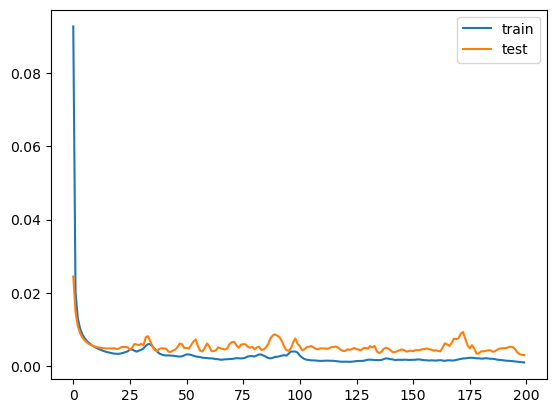

In [40]:
# Plot training results
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend()
plt.show()

In [41]:
torch.save(model.state_dict(), 'autoencoder-sample.pth')

In [42]:
model = Autoencoder(input_dim=100, bottleneck_dim=100)
model.load_state_dict(torch.load('autoencoder-sample.pth'))

<All keys matched successfully>

In [43]:
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=100, out_features=200, bias=True)
    (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=200, out_features=100, bias=True)
    (4): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=100, out_features=100, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=100, out_features=100, bias=True)
    (1): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=100, out_features=200, bias=True)
    (4): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=200, out_features=100, bias=True)
  )
)

In [44]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

In [45]:
print(X_train_tensor)
print(X_test_tensor)

tensor([[0.5367, 0.7498, 0.4264,  ..., 0.4601, 0.5817, 0.4367],
        [0.3605, 0.6624, 0.4767,  ..., 0.5676, 0.7503, 0.4022],
        [0.4418, 0.2538, 0.2608,  ..., 0.4002, 0.3275, 0.8316],
        ...,
        [0.7184, 0.5405, 0.4896,  ..., 0.5222, 0.2027, 0.6769],
        [0.4581, 0.6847, 0.5191,  ..., 0.6214, 0.7491, 0.5600],
        [0.6019, 0.4993, 0.3872,  ..., 0.7525, 0.4159, 0.5969]])
tensor([[0.3240, 0.3375, 0.4691,  ..., 0.2880, 0.5217, 0.5354],
        [0.5719, 0.5668, 0.7041,  ..., 0.4472, 0.5867, 0.5146],
        [0.5822, 0.3691, 0.4584,  ..., 0.5718, 0.5051, 0.5624],
        ...,
        [0.5181, 0.5171, 0.5093,  ..., 0.6247, 0.5943, 0.5005],
        [0.4879, 0.6707, 0.4151,  ..., 0.6616, 0.7708, 0.6468],
        [0.3075, 0.2864, 0.5579,  ..., 0.5298, 0.4481, 0.6083]])


In [46]:
# Get encoded representations
model.eval()
with torch.no_grad():
    X_train_encoded = model.encode(X_train_tensor).numpy()
    X_test_encoded = model.encode(X_test_tensor).numpy()

In [47]:
print(X_train_encoded)
print(X_test_encoded)

[[-0.01094525 -0.3882744   0.89751846 ... -0.69515646  0.24733698
   0.7802091 ]
 [ 0.19285144  0.739434    0.22907907 ... -0.7678509   0.29573125
   0.49931195]
 [ 1.6513432   0.6122445  -0.12960066 ... -0.9372709   0.7090511
  -0.01858993]
 ...
 [-0.93045247 -0.38199687 -0.48653406 ... -0.5915133  -0.4592145
  -0.32013607]
 [ 0.10494934  0.41450265  0.24598855 ... -0.5471286  -0.60089546
  -0.3982437 ]
 [-0.35453808  0.7658688   0.0725804  ...  0.14227048  0.39772996
   0.92937624]]
[[ 1.2077935   1.1836156   0.12948374 ... -0.6478606  -0.01509565
   0.16552636]
 [-0.37895113  0.6524048   0.1075218  ...  0.02480362 -0.5174886
  -0.92543787]
 [-0.56590027  0.81055266 -0.35162446 ...  0.05459053 -0.758301
  -0.71193177]
 ...
 [-0.51366943  0.83322924 -0.5545171  ... -0.46278337  0.14571533
   0.45682323]
 [-0.23970896  0.48209402  0.58681715 ... -0.05158976  0.3561098
  -0.13553227]
 [-0.55189484  1.3316666  -0.09513944 ... -0.06004673 -0.02800982
  -0.4317292 ]]


In [48]:
# Train logistic regression
clf = LogisticRegression()
clf.fit(X_train_encoded, y_train)

LogisticRegression()

In [49]:
# Make predictions
y_pred = clf.predict(X_test_encoded)

In [50]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Classification Accuracy: {accuracy:.4f}')

Classification Accuracy: 0.9273


In [51]:
# Train logistic regression
clf2 = LogisticRegression()
clf2.fit(X_train, y_train)

LogisticRegression()

In [52]:
# Make predictions
y_pred2 = clf2.predict(X_test)

In [53]:
# Calculate accuracy
accuracy2 = accuracy_score(y_test, y_pred2)
print(f'Classification Accuracy: {accuracy2:.4f}')

Classification Accuracy: 0.8939


In [2]:
X_train_encoded.shape

NameError: name 'X_train_encoded' is not defined